In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import pandas as pd

In [8]:
dataset_path = r"C:\Users\PAARTH\Documents\plant-disease-detector\data\plantvillage_dataset\plantvillage dataset\color"
classes = [f for f in os.listdir(dataset_path) 
           if os.path.isdir(os.path.join(dataset_path, f))]

In [ ]:
#frequency of classes
print("Number of classes:", len(classes))
print()

for cls in classes:
    n = len(os.listdir(os.path.join(dataset_path, cls)))
    print(cls, ":", n)

Number of classes: 38

Apple___Apple_scab : 629
Apple___Black_rot : 621
Apple___Cedar_apple_rust : 275
Apple___healthy : 1645
Blueberry___healthy : 1502
Cherry_(including_sour)___healthy : 854
Cherry_(including_sour)___Powdery_mildew : 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513
Corn_(maize)___Common_rust_ : 1192
Corn_(maize)___healthy : 1162
Corn_(maize)___Northern_Leaf_Blight : 985
Grape___Black_rot : 1180
Grape___Esca_(Black_Measles) : 1383
Grape___healthy : 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1076
Orange___Haunglongbing_(Citrus_greening) : 5507
Peach___Bacterial_spot : 2297
Peach___healthy : 360
Pepper,_bell___Bacterial_spot : 997
Pepper,_bell___healthy : 1478
Potato___Early_blight : 1000
Potato___healthy : 152
Potato___Late_blight : 1000
Raspberry___healthy : 371
Soybean___healthy : 5090
Squash___Powdery_mildew : 1835
Strawberry___healthy : 456
Strawberry___Leaf_scorch : 1109
Tomato___Bacterial_spot : 2127
Tomato___Early_blight : 1000
Tomato___health

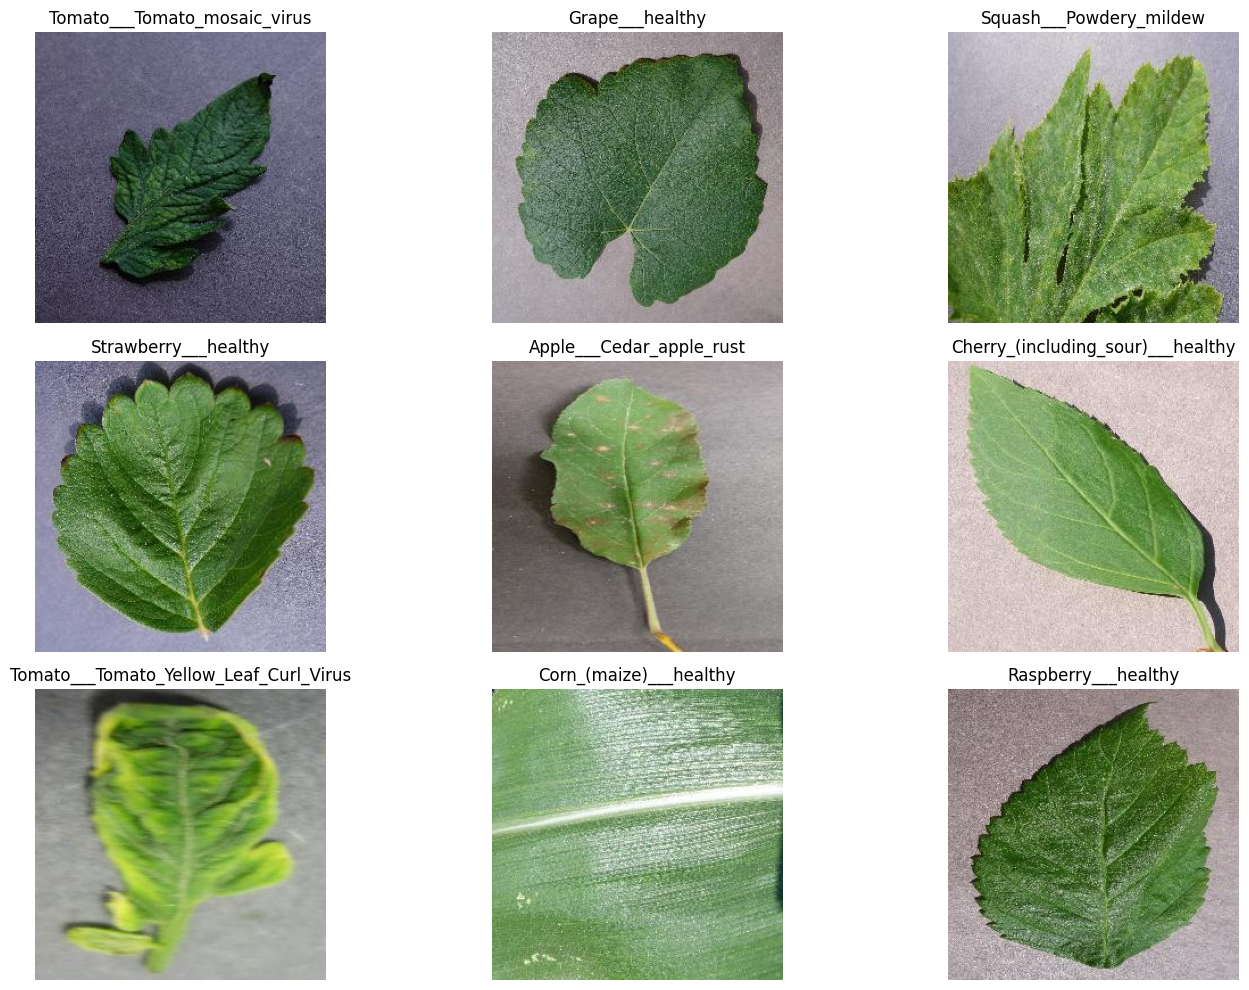

In [ ]:
#just plotting that stuff

plt.figure(figsize=(15,10))

for i in range(9):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    
    img_path = os.path.join(dataset_path, cls, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#image size
sizes = []

for cls in classes:
    folder = os.path.join(dataset_path,cls)
    for img_name in os.listdir(folder)[:20]:
        img = Image.open(os.path.join(folder,img_name))
        sizes.append(img.size)

print(set(sizes))

{(256, 256)}


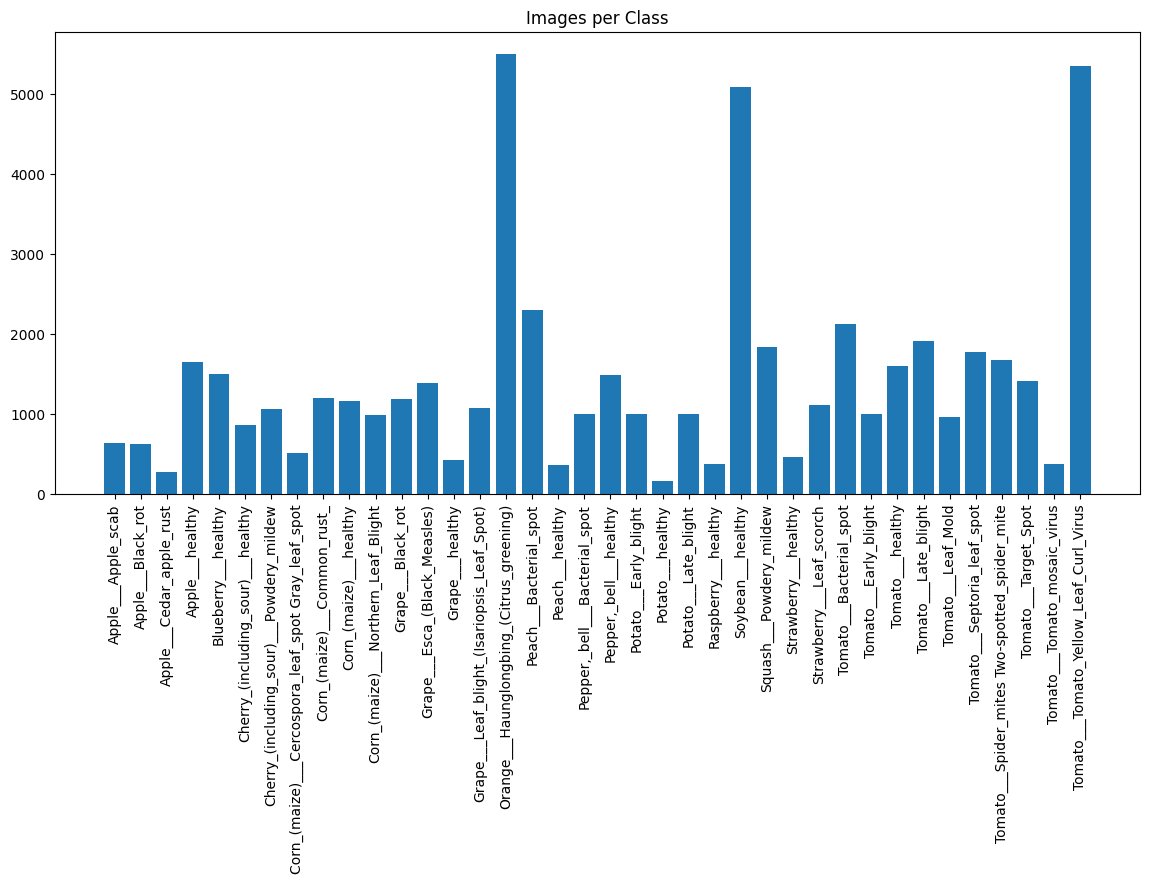

In [12]:
counts = [] #number of images per class

for cls in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path, cls))))

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.bar(classes, counts)
plt.xticks(rotation=90)  #90 degree rotate
plt.title("Images per Class")
plt.show()

In [17]:
rows = []
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    rows.append([cls, len(os.listdir(folder))])

df = pd.DataFrame(rows, columns=['Class','Images'])
df.sort_values('Images', ascending=False)



,Class,Images
15,Orange___Haunglongbing_(Citrus_greening),5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
31,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
33,Tomato___Septoria_leaf_spot,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


In [20]:
print("Smallest->")
print(df.nsmallest(5,'Images'))
print("\n\nLargest->")
print(df.nlargest(5,'Images'))

Smallest->
                           Class  Images
21              Potato___healthy     152
2       Apple___Cedar_apple_rust     275
17               Peach___healthy     360
23           Raspberry___healthy     371
36  Tomato___Tomato_mosaic_virus     373


Largest->
                                       Class  Images
15  Orange___Haunglongbing_(Citrus_greening)    5507
37    Tomato___Tomato_Yellow_Leaf_Curl_Virus    5357
24                         Soybean___healthy    5090
16                    Peach___Bacterial_spot    2297
28                   Tomato___Bacterial_spot    2127
